In [1]:
# ── Java is required (OpenDataLoader is Java-core) ──────────
!apt-get install -y openjdk-17-jdk -qq
!java -version

# ── Install OpenDataLoader ───────────────────────────────────
!pip install -U opendataloader-pdf -q

print("✅ OpenDataLoader installed")

Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 118252 files and directories currently installed.)
Preparing to unpack .../00-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../01-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../02-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../03-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected package at-spi2-core.
Preparing to unpack .../04-at-spi2-core_2.44.0-3_amd64.deb ...
Unpacking at-spi2-core (2.44.0-3) ...
Selecting previously unselected package fonts-dejavu-core.
Prepar

In [2]:
from google.colab import files
import os

uploaded = files.upload()   # upload catmed_1.pdf and catmed_2.pdf
pdf_paths = list(uploaded.keys())

print(f"\n✅ Uploaded {len(pdf_paths)} files:")
for p in pdf_paths:
    print(f"   📄 {p}")

Saving catmed_2.pdf to catmed_2 (1).pdf
Saving catmed_1.pdf to catmed_1 (1).pdf

✅ Uploaded 2 files:
   📄 catmed_2 (1).pdf
   📄 catmed_1 (1).pdf


In [3]:
import opendataloader_pdf
import os

output_dir = "/content/odl_output"
os.makedirs(output_dir, exist_ok=True)

print("🔍 Running OpenDataLoader extraction...")
print("   Formats: JSON + Markdown + HTML")
print("   Mode: Local (no GPU, no API)\n")

opendataloader_pdf.convert(
    input_path  = pdf_paths,          # both PDFs at once
    output_dir  = output_dir,
    format      = "json,markdown",    # JSON for structure, Markdown for readability
    table_method= "cluster",          # better for complex/borderless tables
    reading_order= "xycut",           # XY-Cut++ for correct multi-column order
    quiet       = False               # show progress logs
)

# List output files
print("\n📁 Output files generated:")
for f in os.listdir(output_dir):
    size = os.path.getsize(f"{output_dir}/{f}") // 1024
    print(f"   {f}  ({size} KB)")

🔍 Running OpenDataLoader extraction...
   Formats: JSON + Markdown + HTML
   Mode: Local (no GPU, no API)

May 19, 2026 7:01:44 AM org.opendataloader.pdf.processors.DocumentProcessor preprocessing
INFO: File name: /content/catmed_2 (1).pdf
May 19, 2026 7:01:45 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Number of pages: 32
May 19, 2026 7:01:46 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Author: null
May 19, 2026 7:01:46 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Title: null
May 19, 2026 7:01:46 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Creation date: D:20240520111856+02'00'
May 19, 2026 7:01:46 AM org.opendataloader.pdf.processors.DocumentProcessor calculateDocumentInfo
INFO: Modification date: D:20240520112024+02'00'
May 19, 2026 7:01:46 AM org.opendataloader.pdf.processors.DocumentProcessor processDocument
INFO: Processing 32 p

In [5]:
import os

output_dir = "/content/odl_output"

print("📁 All files in output directory:")
for f in os.listdir(output_dir):
    size = os.path.getsize(f"{output_dir}/{f}")
    print(f"   {f}  →  {size} bytes")

📁 All files in output directory:
   catmed_1 (1)_images  →  4096 bytes
   catmed_1 (1).json  →  299774 bytes
   catmed_2 (1).md  →  20781 bytes
   catmed_2 (1)_images  →  4096 bytes
   catmed_2 (1).json  →  118281 bytes
   catmed_1 (1).md  →  39452 bytes


In [6]:
import json, glob

json_files = glob.glob(f"{output_dir}/*.json")

print(f"Found {len(json_files)} JSON files\n")

for jf in json_files:
    print(f"{'='*50}")
    print(f"File: {jf}")

    with open(jf, "r", encoding="utf-8") as f:
        raw = f.read()

    print(f"File size     : {len(raw)} characters")
    print(f"First 500 chars:\n{raw[:500]}")
    print()

Found 2 JSON files

File: /content/odl_output/catmed_1 (1).json
File size     : 299386 characters
First 500 chars:
{
  "file name" : "catmed_1 (1).pdf",
  "number of pages" : 28,
  "author" : null,
  "title" : null,
  "creation date" : "D:20240207171246-07'00'",
  "modification date" : "D:20240207171301-07'00'",
  "kids" : [ {
    "type" : "paragraph",
    "id" : 151,
    "page number" : 1,
    "bounding box" : [ 30.96, 599.34, 335.52, 647.34 ],
    "font" : "Gilroy-Light",
    "font size" : 40.0,
    "text color" : "[0.0, 0.0, 0.0, 0.85]",
    "content" : "Instrument focus"
  }, {
    "type" : "heading",
  

File: /content/odl_output/catmed_2 (1).json
File size     : 118263 characters
First 500 chars:
{
  "file name" : "catmed_2 (1).pdf",
  "number of pages" : 32,
  "author" : null,
  "title" : null,
  "creation date" : "D:20240520111856+02'00'",
  "modification date" : "D:20240520112024+02'00'",
  "kids" : [ {
    "type" : "paragraph",
    "id" : 43,
    "page number" : 1,
    "bound

In [7]:
# Once you know the structure, this will find the elements

for jf in json_files:
    with open(jf, "r", encoding="utf-8") as f:
        data = json.load(f)

    print(f"File: {jf}")
    print(f"Type of data  : {type(data)}")

    if isinstance(data, dict):
        print(f"Top-level keys: {list(data.keys())}")

        # Try common key names
        for key in ["elements", "pages", "content",
                    "blocks", "items", "data", "result"]:
            if key in data:
                val = data[key]
                print(f"  → Found key '{key}': {type(val)}, length={len(val) if hasattr(val,'__len__') else 'N/A'}")
                if isinstance(val, list) and len(val) > 0:
                    print(f"     First item keys: {list(val[0].keys()) if isinstance(val[0], dict) else val[0]}")

    elif isinstance(data, list):
        print(f"List length   : {len(data)}")
        if len(data) > 0:
            print(f"First item    : {json.dumps(data[0], indent=2)[:300]}")

    print()

File: /content/odl_output/catmed_1 (1).json
Type of data  : <class 'dict'>
Top-level keys: ['file name', 'number of pages', 'author', 'title', 'creation date', 'modification date', 'kids']

File: /content/odl_output/catmed_2 (1).json
Type of data  : <class 'dict'>
Top-level keys: ['file name', 'number of pages', 'author', 'title', 'creation date', 'modification date', 'kids']



In [8]:
md_files = glob.glob(f"{output_dir}/*.md") + glob.glob(f"{output_dir}/*.markdown")

print(f"Found {len(md_files)} Markdown files\n")

for mf in md_files:
    with open(mf, "r", encoding="utf-8") as f:
        content = f.read()
    print(f"File: {mf}")
    print(f"Size: {len(content)} chars")
    print(f"First 500 chars:\n{content[:500]}")
    print()

Found 2 Markdown files

File: /content/odl_output/catmed_2 (1).md
Size: 20763 chars
First 500 chars:
STILLE

Surgical Instruments

Selected Models

![image 1](<catmed_2 (1)_images/imageFile1.png>)

![image 2](<catmed_2 (1)_images/imageFile2.png>)

![image 3](<catmed_2 (1)_images/imageFile3.png>)

![image 4](<catmed_2 (1)_images/imageFile4.png>)

![image 5](<catmed_2 (1)_images/imageFile5.png>)

2 | STILLE Surgical Instruments

STILLE Surgical Instruments Selected Models

Art. no: 950-G100-0001-EN-01. Photos: Åke Gunnarsson, Vue and Jonas Frid, Studio Roland, Fanny Eriksson Palm Printing: Arkite

File: /content/odl_output/catmed_1 (1).md
Size: 39064 chars
First 500 chars:
Instrument focus

### catalog

![image 1](<catmed_1 (1)_images/imageFile1.png>)

# Securos veterinary surgical instruments

02

Securos Surgical offers a complete line of premium quality German stainless steel surgical instruments designed and selected with the veterinary surgeon in mind. These instruments are manufact

In [9]:
import json
import glob
import os
from collections import Counter

output_dir = "/content/odl_output"

# ── Load all JSON files ──────────────────────────────────────
json_files = glob.glob(f"{output_dir}/*.json")
all_documents = {}

for jf in json_files:
    pdf_name = os.path.basename(jf).replace(".json", "")

    with open(jf, "r", encoding="utf-8") as f:
        data = json.load(f)

    # ── OpenDataLoader uses "kids" as the elements key ───────
    elements = data.get("kids", [])

    # ── Inject page_number from "page number" (space, not underscore)
    for el in elements:
        if "page_number" not in el:
            el["page_number"] = el.get("page number", 1)

    # ── Store metadata alongside elements ────────────────────
    all_documents[pdf_name] = {
        "metadata": {
            "file_name"    : data.get("file name"),
            "num_pages"    : data.get("number of pages"),
            "author"       : data.get("author"),
            "title"        : data.get("title"),
            "created"      : data.get("creation date"),
            "modified"     : data.get("modification date"),
        },
        "elements": elements
    }

    # ── Summary ──────────────────────────────────────────────
    print(f"\n📄 {pdf_name}")
    print(f"   File           : {data.get('file name')}")
    print(f"   Pages          : {data.get('number of pages')}")
    print(f"   Total elements : {len(elements)}")

    if elements:
        type_counts = Counter(el.get("type", "unknown") for el in elements)
        print(f"\n   Element Breakdown:")
        for t, c in type_counts.most_common():
            print(f"     {t:<20} → {c}")
    else:
        print("   ⚠️ Still 0 elements")


📄 catmed_1 (1)
   File           : catmed_1 (1).pdf
   Pages          : 28
   Total elements : 465

   Element Breakdown:
     paragraph            → 274
     heading              → 55
     image                → 53
     list                 → 38
     header               → 25
     footer               → 12
     table                → 5
     caption              → 3

📄 catmed_2 (1)
   File           : catmed_2 (1).pdf
   Pages          : 32
   Total elements : 383

   Element Breakdown:
     paragraph            → 268
     image                → 87
     header               → 11
     list                 → 7
     heading              → 6
     caption              → 4


In [10]:
import random

def display_page_elements(pdf_name, doc, page_num):
    elements = [el for el in doc["elements"]
                if el.get("page_number") == page_num]
    meta     = doc["metadata"]

    print(f"\n{'='*65}")
    print(f"  📄 {pdf_name}  |  Page {page_num}/{meta['num_pages']}  |  {len(elements)} elements")
    print(f"{'='*65}")

    if not elements:
        print("  ⚠️  No elements on this page")
        return

    for i, el in enumerate(elements):
        el_type  = el.get("type", "unknown")
        content  = el.get("content", "").strip()
        bbox     = el.get("bounding box", "N/A")   # note: space not underscore
        font     = el.get("font", "")
        fontsize = el.get("font size", "")
        color    = el.get("text color", "")
        el_id    = el.get("id", "")
        level    = el.get("heading level", "")

        if el_type == "heading":
            print(f"\n  🔷 [{i+1}] HEADING  (id={el_id}, level={level})")
            print(f"      Content  : {content[:120]}")
            print(f"      Font     : {font} {fontsize}pt")
            print(f"      BBox     : {bbox}")
            print(f"      Color    : {color}")

        elif el_type == "paragraph":
            print(f"\n  📝 [{i+1}] PARAGRAPH  (id={el_id})")
            print(f"      Content  : {content[:200]}{'...' if len(content)>200 else ''}")
            print(f"      Font     : {font} {fontsize}pt")
            print(f"      BBox     : {bbox}")

        elif el_type == "table":
            rows = el.get("rows", el.get("cells", []))
            print(f"\n  📊 [{i+1}] TABLE  (id={el_id}, {len(rows)} rows)")
            print(f"      Content  : {content[:150]}{'...' if len(content)>150 else ''}")
            print(f"      BBox     : {bbox}")
            if rows:
                print(f"      Rows preview:")
                for r in rows[:3]:
                    print(f"        {r}")

        elif el_type == "image":
            caption = el.get("caption", content[:80])
            img_path = el.get("path", el.get("image_path", ""))
            print(f"\n  🖼️  [{i+1}] IMAGE  (id={el_id})")
            print(f"      Caption  : {caption}")
            print(f"      Path     : {img_path}")
            print(f"      BBox     : {bbox}")

        elif el_type == "list":
            items = el.get("items", [])
            print(f"\n  📋 [{i+1}] LIST  (id={el_id}, {len(items)} items)")
            print(f"      Content  : {content[:150]}")
            print(f"      BBox     : {bbox}")

        else:
            print(f"\n  ❓ [{i+1}] {el_type.upper()}  (id={el_id})")
            print(f"      Content  : {content[:120]}")
            print(f"      BBox     : {bbox}")


# ── Collect all (pdf_name, page_number) pairs ────────────────
all_pages = []
for pdf_name, doc in all_documents.items():
    page_nums = sorted(set(
        el.get("page_number", 1) for el in doc["elements"]
    ))
    for pg in page_nums:
        all_pages.append((pdf_name, pg))

print(f"Total pages available across all PDFs: {len(all_pages)}")
for pdf_name, doc in all_documents.items():
    print(f"  {pdf_name} → {doc['metadata']['num_pages']} pages")

# ── Randomly sample 5 pages ──────────────────────────────────
random.seed(42)
sampled = random.sample(all_pages, min(5, len(all_pages)))

print(f"\n🎲 Randomly sampled 5 pages:")
for pdf_name, pg in sampled:
    print(f"   {pdf_name}  →  Page {pg}")

# ── Display ───────────────────────────────────────────────────
for pdf_name, pg in sampled:
    display_page_elements(pdf_name, all_documents[pdf_name], pg)

Total pages available across all PDFs: 60
  catmed_1 (1) → 28 pages
  catmed_2 (1) → 32 pages

🎲 Randomly sampled 5 pages:
   catmed_2 (1)  →  Page 13
   catmed_1 (1)  →  Page 8
   catmed_1 (1)  →  Page 2
   catmed_2 (1)  →  Page 20
   catmed_1 (1)  →  Page 18

  📄 catmed_2 (1)  |  Page 13/32  |  18 elements

  🖼️  [1] IMAGE  (id=220)
      Caption  : 
      Path     : 
      BBox     : [-64.115, 235.229, 557.376, 650.955]

  📝 [2] PARAGRAPH  (id=215)
      Content  : STILLE Selected Models | 13
      Font     : FoundrySterling-Demi 8.0pt
      BBox     : [670.032, 551.644, 805.89, 560.908]

  🖼️  [3] IMAGE  (id=218)
      Caption  : 
      Path     : 
      BBox     : [429.055, 333.943, 738.889, 524.806]

  📝 [4] PARAGRAPH  (id=222)
      Content  : PEAN STILLE ARTERY FORCEPS
      Font     : FoundrySterling-Demi 10.0pt
      BBox     : [106.654, 372.622, 241.481, 384.202]

  📝 [5] PARAGRAPH  (id=225)
      Content  : CRILE STILLE ARTERY FORCEPS
      Font     : FoundrySterling-Demi 1

In [11]:
print("📦 RAW JSON — One element per sampled page (exact OpenDataLoader format):\n")

for pdf_name, pg in sampled[:2]:
    doc      = all_documents[pdf_name]
    page_els = [el for el in doc["elements"] if el.get("page_number") == pg]

    if page_els:
        print(f"── {pdf_name}  |  Page {pg} ──────────────────────")
        print(json.dumps(page_els[0], indent=2, ensure_ascii=False))
        print()

📦 RAW JSON — One element per sampled page (exact OpenDataLoader format):

── catmed_2 (1)  |  Page 13 ──────────────────────
{
  "type": "image",
  "id": 220,
  "page number": 13,
  "bounding box": [
    -64.115,
    235.229,
    557.376,
    650.955
  ],
  "source": "catmed_2 (1)_images/imageFile32.png",
  "page_number": 13
}

── catmed_1 (1)  |  Page 8 ──────────────────────
{
  "type": "header",
  "id": 280,
  "page number": 8,
  "bounding box": [
    75.48,
    753.345,
    178.106,
    764.37
  ],
  "kids": [
    {
      "type": "heading",
      "id": 56,
      "page number": 8,
      "bounding box": [
        75.48,
        753.345,
        178.106,
        764.37
      ],
      "heading level": 11,
      "font": "Gilroy-Regular",
      "font size": 9.0,
      "text color": "[0.7, 0.05, 0.0, 0.0]",
      "content": "Instrument focus catalog"
    }
  ],
  "page_number": 8
}



In [12]:
import pandas as pd

rows = []
for pdf_name, pg in sampled:
    doc      = all_documents[pdf_name]
    page_els = [el for el in doc["elements"] if el.get("page_number") == pg]

    for el in page_els:
        rows.append({
            "pdf"          : pdf_name,
            "page"         : pg,
            "id"           : el.get("id", ""),
            "type"         : el.get("type", ""),
            "content"      : el.get("content", "")[:300],
            "bounding_box" : str(el.get("bounding box", "")),
            "font"         : el.get("font", ""),
            "font_size"    : el.get("font size", ""),
            "heading_level": el.get("heading level", ""),
            "text_color"   : el.get("text color", "")
        })

df = pd.DataFrame(rows)
df.to_csv("/content/sampled_pages_output.csv", index=False)

print(f"✅ Saved {len(rows)} elements from 5 pages")
print(f"\nElement type breakdown:")
print(df["type"].value_counts().to_string())
print(f"\nPreview (first 10 rows):")
df.head(10)

✅ Saved 112 elements from 5 pages

Element type breakdown:
type
paragraph    86
image        15
heading       6
header        4
list          1

Preview (first 10 rows):


,pdf,page,id,type,content,bounding_box,font,font_size,heading_level,text_color
0,catmed_2 (1),13,220,image,,"[-64.115, 235.229, 557.376, 650.955]",,,,
1,catmed_2 (1),13,215,paragraph,STILLE Selected Models | 13,"[670.032, 551.644, 805.89, 560.908]",FoundrySterling-Demi,8.0,,"[0.11, 0.0, 0.0, 0.65]"
2,catmed_2 (1),13,218,image,,"[429.055, 333.943, 738.889, 524.806]",,,,
3,catmed_2 (1),13,222,paragraph,PEAN STILLE ARTERY FORCEPS,"[106.654, 372.622, 241.481, 384.202]",FoundrySterling-Demi,10.0,,"[0.0, 1.0, 0.65, 0.15]"
4,catmed_2 (1),13,225,paragraph,CRILE STILLE ARTERY FORCEPS,"[440.433, 372.622, 576.341, 384.202]",FoundrySterling-Demi,10.0,,"[0.0, 1.0, 0.65, 0.15]"
5,catmed_2 (1),13,223,paragraph,Art. Number: 103-10015-131,"[106.654, 359.256, 196.692, 368.383]",FoundrySterling-BookItalicOSF,8.0,,"[0.0, 0.0, 0.0, 0.88]"
6,catmed_2 (1),13,226,paragraph,Art. Number: 103-10182-161,"[440.433, 359.256, 529.824, 368.383]",FoundrySterling-BookItalicOSF,8.0,,"[0.0, 0.0, 0.0, 0.88]"
7,catmed_2 (1),13,224,paragraph,General utility forceps used in many surgical ...,"[106.654, 335.812, 223.325, 354.532]",FoundrySterling-Book,8.0,,"[0.0, 0.0, 0.0, 0.88]"
8,catmed_2 (1),13,227,paragraph,General purpose hemostat without teeth. Used i...,"[440.433, 326.212, 594.351, 354.532]",FoundrySterling-Book,8.0,,"[0.0, 0.0, 0.0, 0.88]"
9,catmed_2 (1),13,219,image,,"[432.271, 106.991, 721.605, 283.982]",,,,


In [13]:
# ── Install visualization dependencies ───────────────────────
!pip install pymupdf pillow -q
print("✅ Dependencies ready")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 25.5 MB/s eta 0:00:00
✅ Dependencies ready


In [14]:
import fitz          # PyMuPDF — renders PDF pages to images
import json
import random
import os
import glob
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display
import io

# ── Color map per element type ───────────────────────────────
TYPE_COLORS = {
    "heading"   : (220,  53,  69, 120),   # red
    "paragraph" : ( 13, 110, 253, 100),   # blue
    "table"     : ( 25, 135,  84, 120),   # green
    "image"     : (255, 193,   7, 120),   # yellow
    "list"      : (111,  66, 193, 120),   # purple
    "caption"   : (  0, 202, 202, 120),   # cyan
}
LABEL_COLORS = {
    "heading"   : (220,  53,  69, 255),
    "paragraph" : ( 13, 110, 253, 255),
    "table"     : ( 25, 135,  84, 255),
    "image"     : (200, 150,   0, 255),
    "list"      : (111,  66, 193, 255),
    "caption"   : (  0, 150, 150, 255),
}
DEFAULT_COLOR       = (108, 117, 125, 100)
DEFAULT_LABEL_COLOR = (108, 117, 125, 255)


def odl_bbox_to_pixel(bbox, page_height_pt, scale):
    """
    OpenDataLoader bbox format: [left, bottom, right, top]
    PDF coordinate origin is BOTTOM-LEFT, y increases upward.
    PIL origin is TOP-LEFT, y increases downward.
    So we flip the y-axis.

    Returns (x0, y0, x1, y1) in pixel space.
    """
    left, bottom, right, top = bbox
    x0 = left   * scale
    y0 = (page_height_pt - top)    * scale   # flip top
    x1 = right  * scale
    y1 = (page_height_pt - bottom) * scale   # flip bottom
    return x0, y0, x1, y1


def render_page_with_boxes(pdf_path, page_num_1indexed, elements, scale=2.0):
    """
    Renders one PDF page and draws bounding boxes + labels
    for every extracted element on that page.
    Returns a PIL Image.
    """
    doc  = fitz.open(pdf_path)
    page = doc[page_num_1indexed - 1]          # fitz is 0-indexed

    page_height_pt = page.rect.height          # PDF points
    page_width_pt  = page.rect.width

    # ── Render page to image ─────────────────────────────────
    mat = fitz.Matrix(scale, scale)
    pix = page.get_pixmap(matrix=mat, alpha=False)
    img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
    doc.close()

    # ── Draw overlay ─────────────────────────────────────────
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    draw    = ImageDraw.Draw(overlay)

    page_elements = [el for el in elements
                     if el.get("page_number") == page_num_1indexed]

    for el in page_elements:
        bbox    = el.get("bounding box")
        el_type = el.get("type", "unknown").lower()
        content = el.get("content", "")[:40]
        el_id   = el.get("id", "")

        if not bbox or len(bbox) != 4:
            continue

        x0, y0, x1, y1 = odl_bbox_to_pixel(
            bbox, page_height_pt, scale
        )

        fill_color  = TYPE_COLORS.get(el_type,  DEFAULT_COLOR)
        label_color = LABEL_COLORS.get(el_type, DEFAULT_LABEL_COLOR)

        # ── Filled semi-transparent rectangle ────────────────
        draw.rectangle([x0, y0, x1, y1], fill=fill_color)

        # ── Solid border ─────────────────────────────────────
        border = label_color[:3] + (255,)
        draw.rectangle([x0, y0, x1, y1], outline=border, width=2)

        # ── Label tag (type + id) ─────────────────────────────
        label = f" {el_type} #{el_id} "
        tx    = x0 + 3
        ty    = max(y0 - 16, 0)
        draw.rectangle(
            [tx - 2, ty, tx + len(label) * 6, ty + 14],
            fill=border
        )
        draw.text((tx, ty), label, fill=(255, 255, 255, 255))

    # ── Merge overlay onto page ───────────────────────────────
    img_rgba = img.convert("RGBA")
    combined = Image.alpha_composite(img_rgba, overlay)
    return combined.convert("RGB")


def draw_legend(draw, x, y):
    """Draws a legend in the top-right corner."""
    items = list(TYPE_COLORS.items())
    bw, bh, pad = 14, 14, 4

    draw.rectangle([x-8, y-8,
                    x + 120, y + len(items)*(bh+pad) + 8],
                   fill=(255,255,255,220), outline=(180,180,180))

    for i, (etype, color) in enumerate(items):
        cy = y + i * (bh + pad)
        draw.rectangle([x, cy, x+bw, cy+bh],
                        fill=color[:3], outline=(80,80,80))
        draw.text((x + bw + 6, cy), etype, fill=(30,30,30))


def show_sampled_pages_with_boxes(sampled, all_documents, pdf_paths, scale=2.0):
    """
    Main function: for each sampled (pdf_name, page) pair,
    renders the page with bounding boxes and displays it inline.
    """
    # Map pdf_name → actual file path
    path_map = {}
    for path in pdf_paths:
        name = os.path.basename(path).replace(".pdf","").replace(".PDF","")
        path_map[name] = path

    for pdf_name, pg in sampled:
        doc      = all_documents[pdf_name]
        elements = doc["elements"]
        meta     = doc["metadata"]

        # Match pdf_name to file path (names may have spaces/parens)
        pdf_file = None
        for name, path in path_map.items():
            if name in pdf_name or pdf_name in name:
                pdf_file = path
                break

        if not pdf_file:
            # fallback: try exact match
            for path in pdf_paths:
                if pdf_name in path:
                    pdf_file = path
                    break

        if not pdf_file:
            print(f"⚠️  Could not find PDF file for: {pdf_name}")
            print(f"    Available: {list(path_map.keys())}")
            continue

        page_els = [el for el in elements
                    if el.get("page_number") == pg]

        print(f"\n{'='*60}")
        print(f"  📄 {pdf_name}  |  Page {pg}/{meta['num_pages']}")
        print(f"  🎯 Elements on this page: {len(page_els)}")

        from collections import Counter
        type_counts = Counter(el.get("type","?") for el in page_els)
        for t,c in type_counts.most_common():
            color_label = "🔴" if t=="heading" else \
                          "🔵" if t=="paragraph" else \
                          "🟢" if t=="table" else \
                          "🟡" if t=="image" else \
                          "🟣" if t=="list"  else "⚫"
            print(f"     {color_label} {t:<15} → {c}")
        print(f"{'='*60}")

        # Render
        img = render_page_with_boxes(pdf_file, pg, elements, scale=scale)

        # Add legend
        draw   = ImageDraw.Draw(img)
        leg_x  = img.width - 140
        leg_y  = 20
        draw_legend(draw, leg_x, leg_y)

        # Add page info banner at top
        draw.rectangle([0, 0, img.width, 28], fill=(30,30,30))
        draw.text((8, 6),
                  f"  {pdf_name}  |  Page {pg}  |  "
                  f"{len(page_els)} elements",
                  fill=(255,255,255))

        # Display
        display(img)

        # Save individual page
        save_path = f"/content/page_{pdf_name}_p{pg}.png"
        img.save(save_path)
        print(f"  💾 Saved → {save_path}\n")


  📄 catmed_2 (1)  |  Page 13/32
  🎯 Elements on this page: 18
     🔵 paragraph       → 14
     🟡 image           → 4


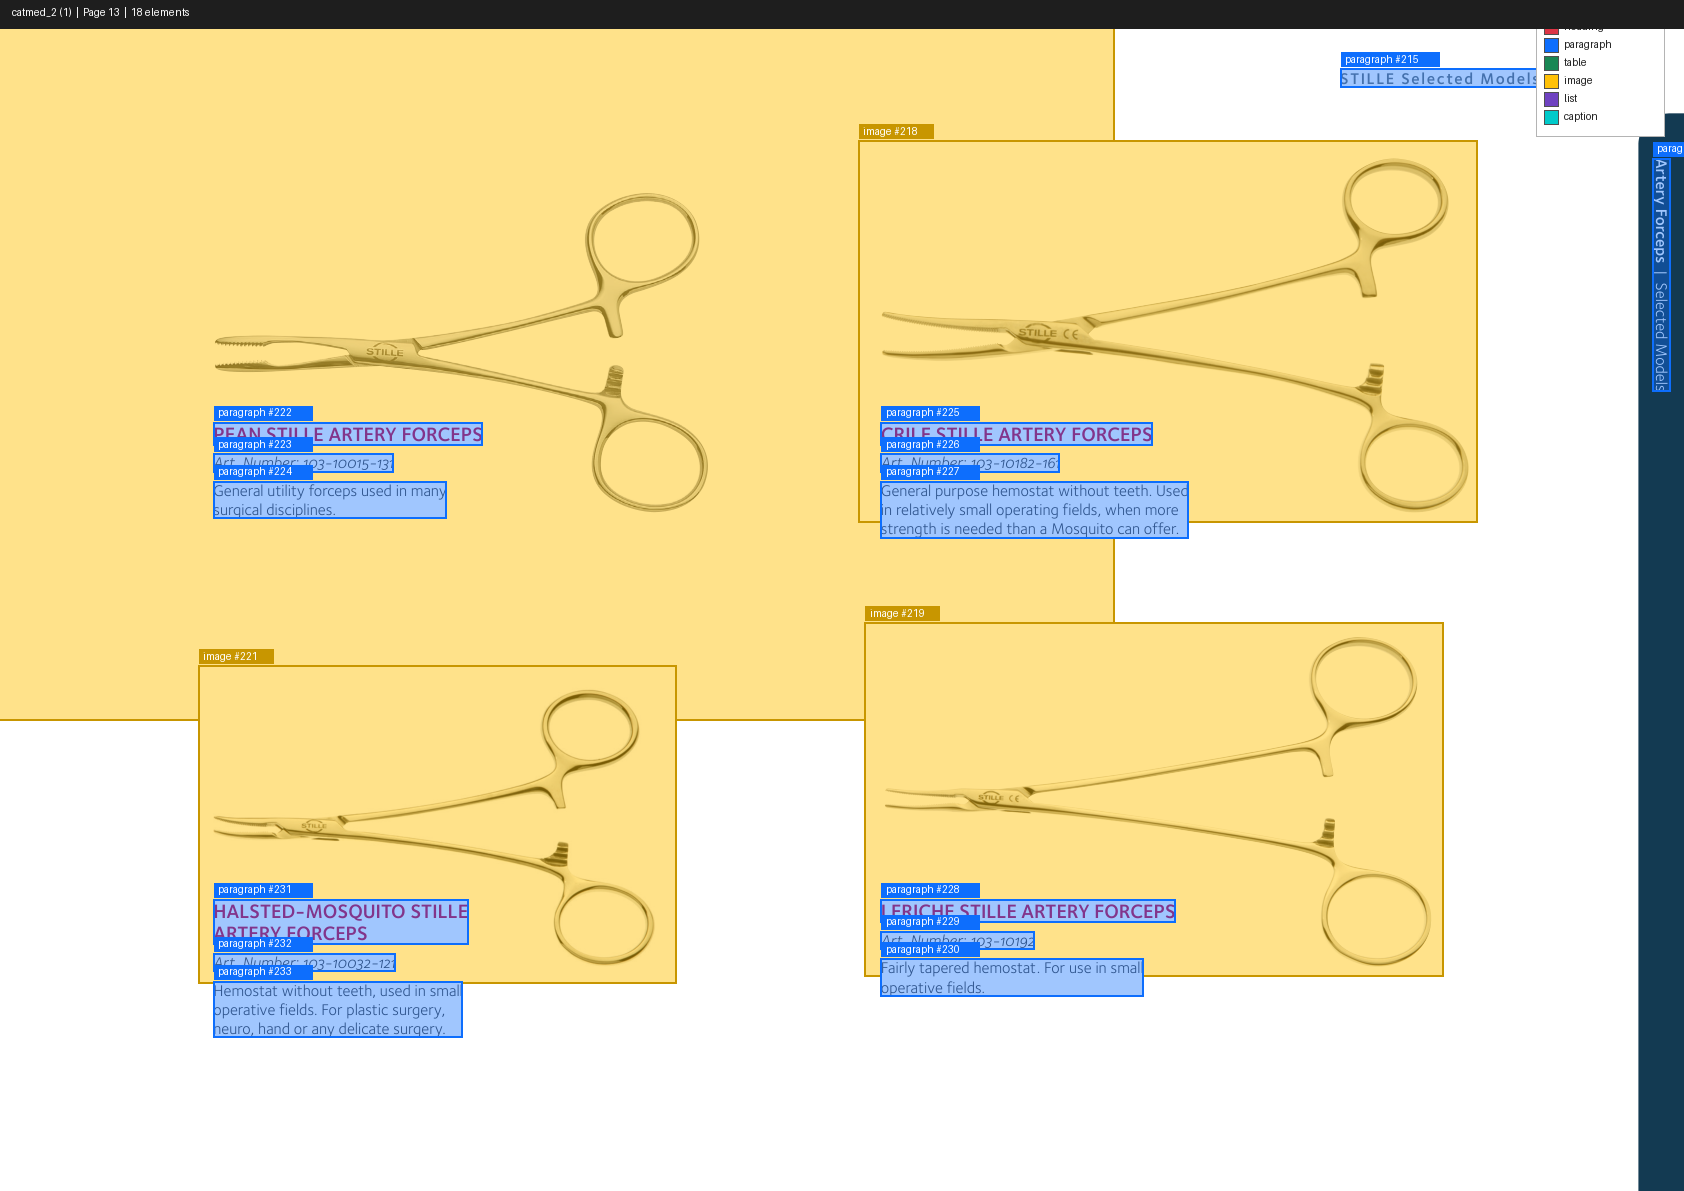

  💾 Saved → /content/page_catmed_2 (1)_p13.png


  📄 catmed_1 (1)  |  Page 8/28
  🎯 Elements on this page: 47
     🔵 paragraph       → 41
     🔴 heading         → 2
     🟡 image           → 2
     ⚫ header          → 1
     🟣 list            → 1


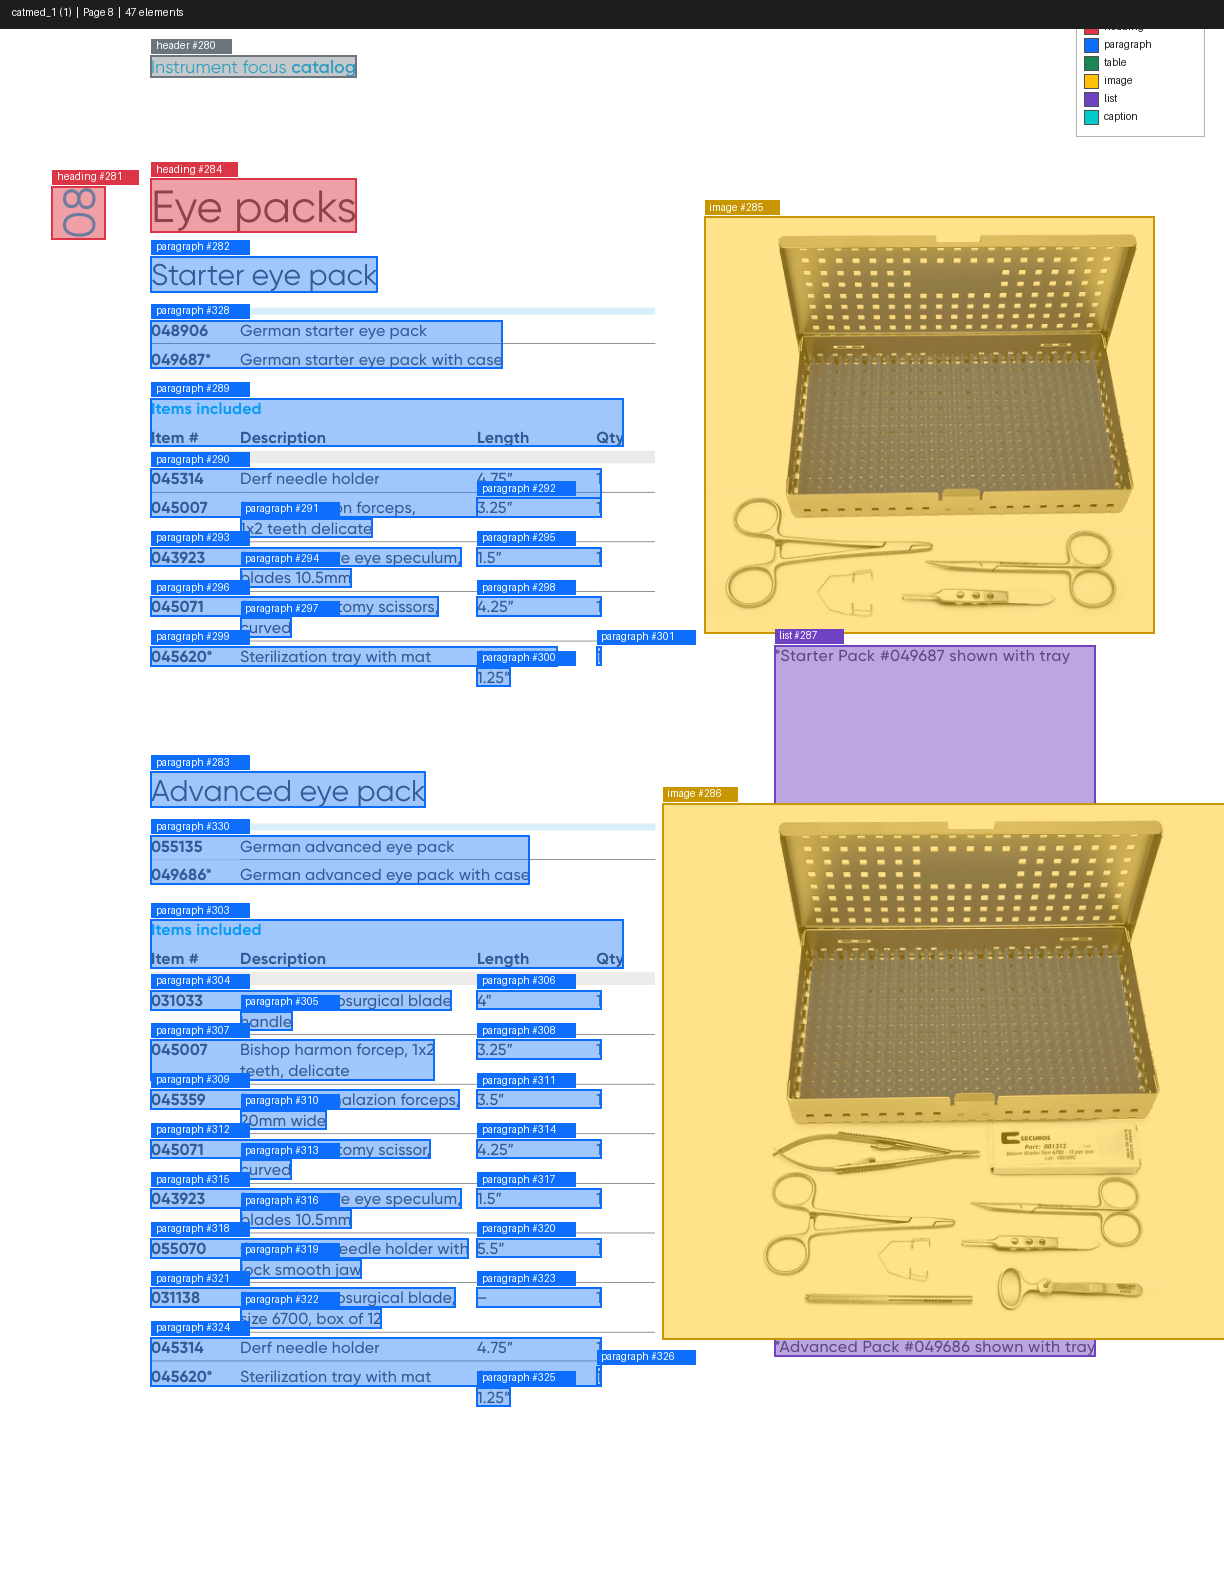

  💾 Saved → /content/page_catmed_1 (1)_p8.png


  📄 catmed_1 (1)  |  Page 2/28
  🎯 Elements on this page: 13
     🔵 paragraph       → 9
     🔴 heading         → 2
     ⚫ header          → 1
     🟡 image           → 1


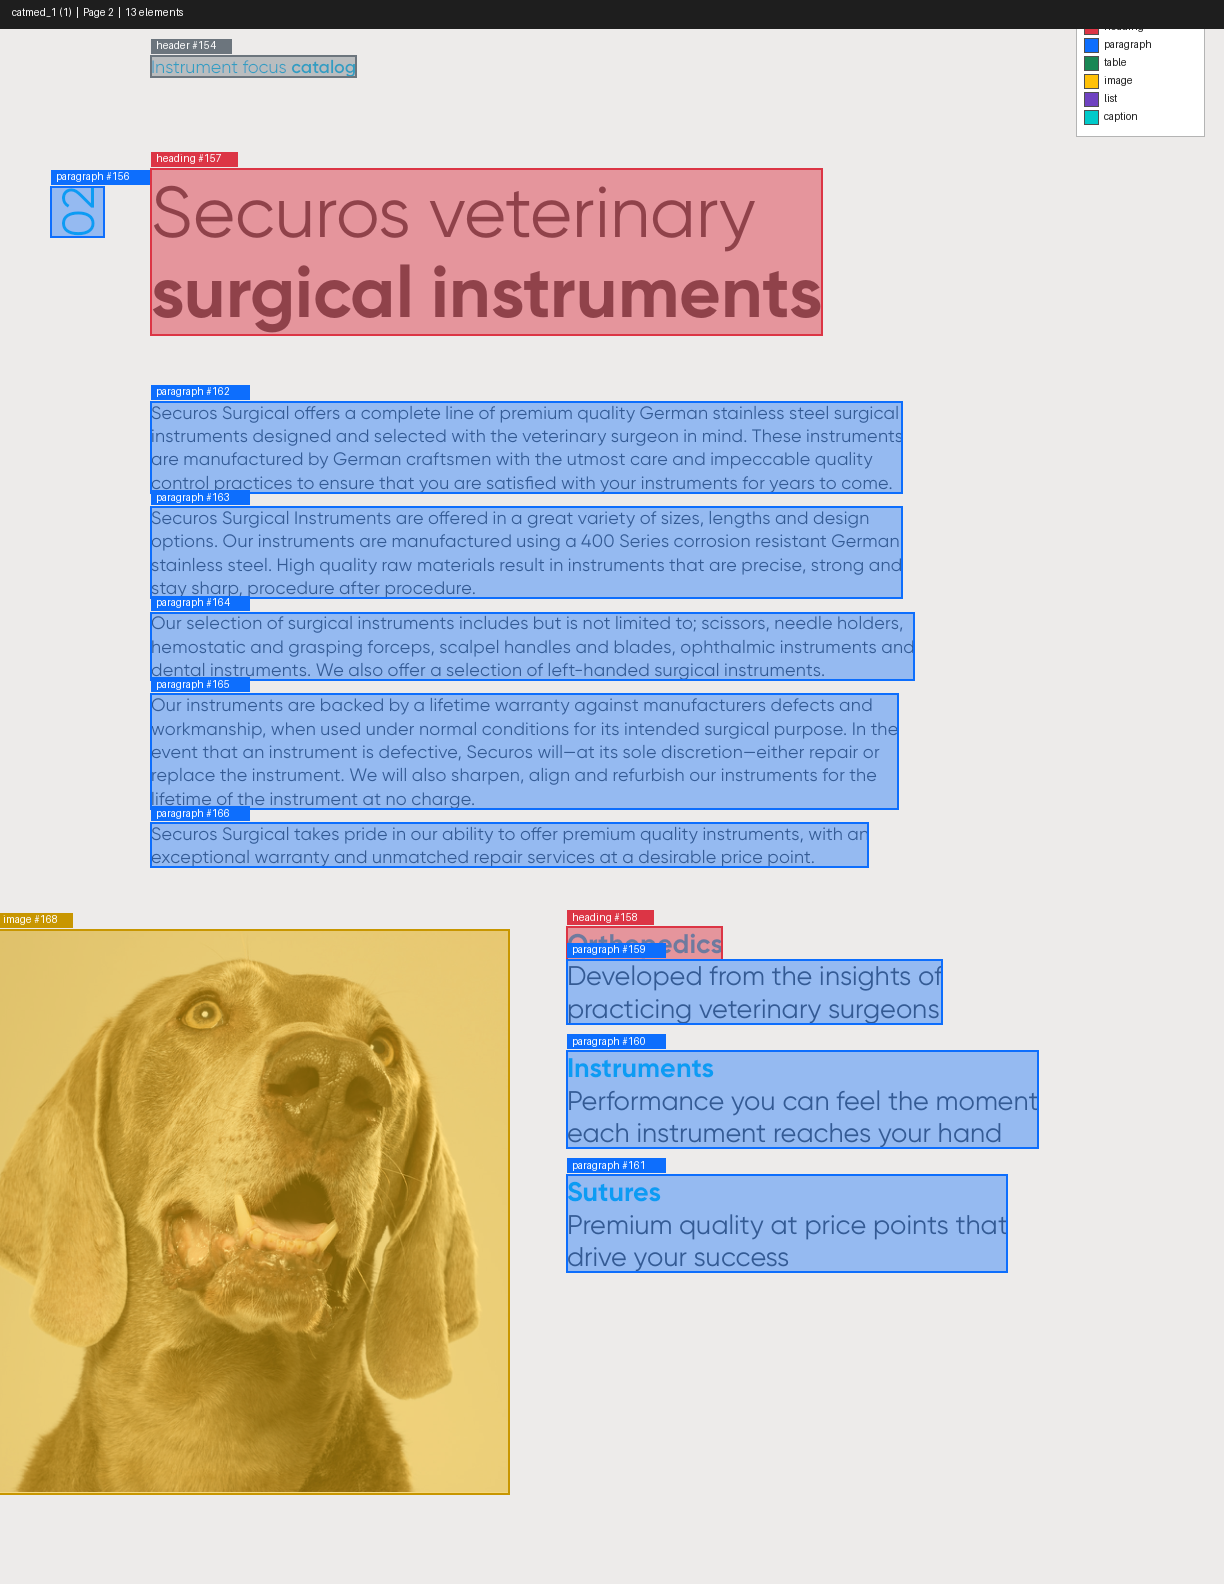

  💾 Saved → /content/page_catmed_1 (1)_p2.png


  📄 catmed_2 (1)  |  Page 20/32
  🎯 Elements on this page: 8
     🔵 paragraph       → 5
     🟡 image           → 2
     ⚫ header          → 1


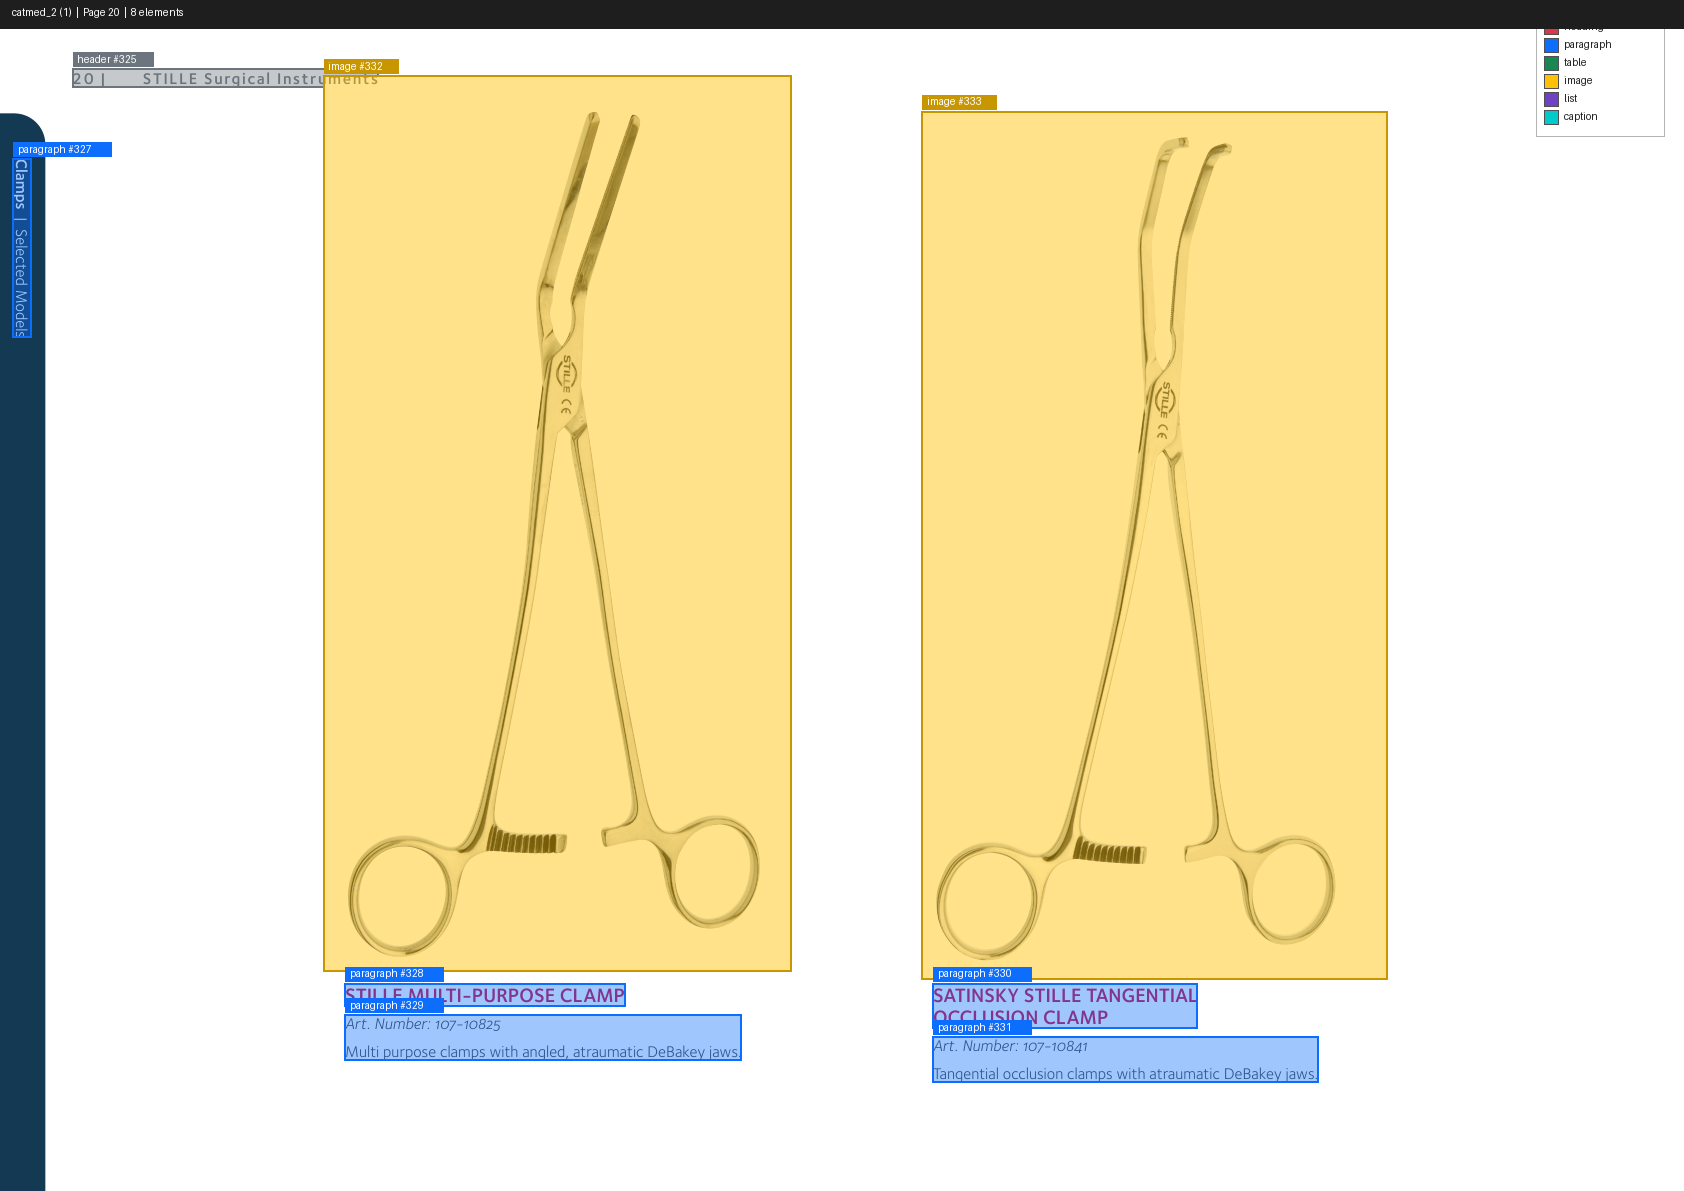

  💾 Saved → /content/page_catmed_2 (1)_p20.png


  📄 catmed_1 (1)  |  Page 18/28
  🎯 Elements on this page: 26
     🔵 paragraph       → 17
     🟡 image           → 6
     🔴 heading         → 2
     ⚫ header          → 1


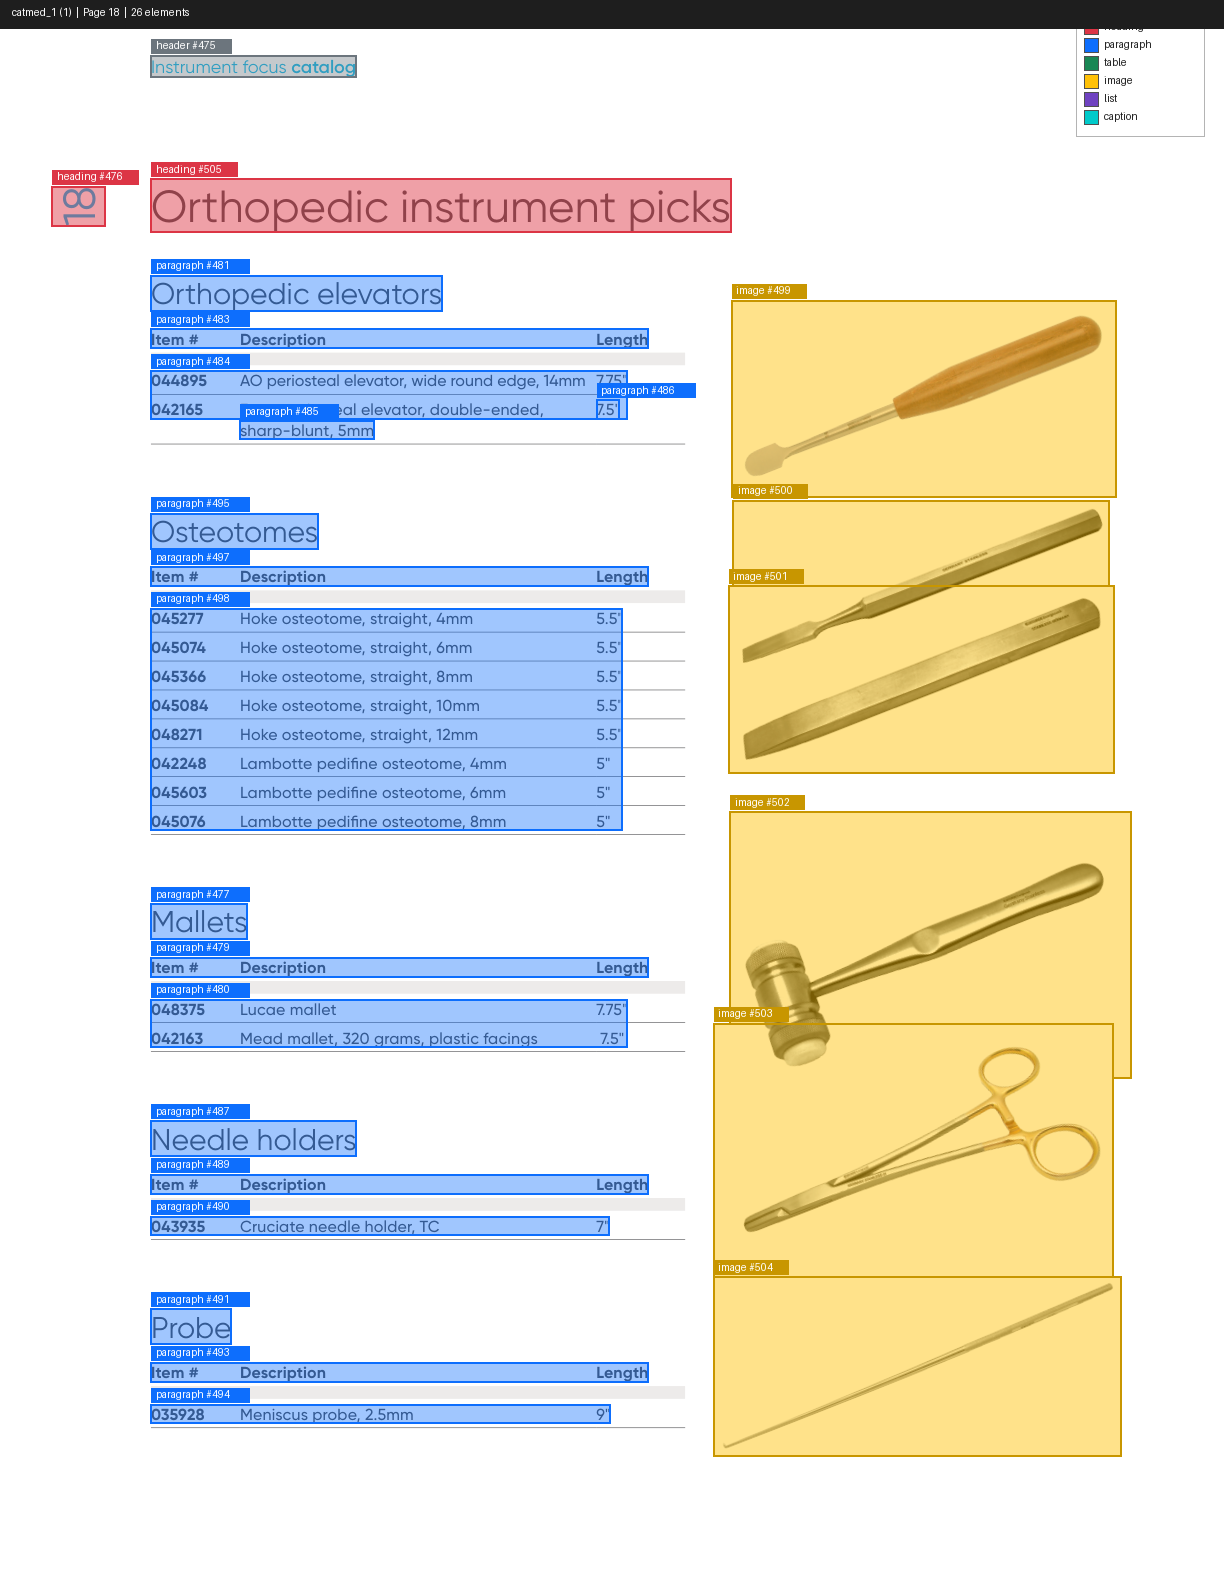

  💾 Saved → /content/page_catmed_1 (1)_p18.png



In [15]:
# ── Run it ───────────────────────────────────────────────────
show_sampled_pages_with_boxes(
    sampled      = sampled,         # your 5 random (pdf_name, page) pairs
    all_documents= all_documents,   # loaded in Cell 4
    pdf_paths    = pdf_paths,       # uploaded in Cell 2
    scale        = 2.0              # 2x = sharper; lower if running slow
)